### Esercitazione clustering CluStream

In [12]:
import random
from influxdb_client import InfluxDBClient, BucketsApi, BucketRetentionRules, Point, WritePrecision
from datetime import datetime, timedelta, timezone
import influxdb_client
import psutil
import numpy as np
import random, time
import pandas as pd
from sklearn.cluster import KMeans
from river import cluster
import matplotlib.pyplot as plt

# Setup e connessione al server InfluxDB
org_name = "spamic"
token = "6ANpdrZyP8Nk7HBib5puP7dx8fJrFNG2xCPlBiXqDSKAsSfjKsUMPlgEVvoQMllyP0HCDAlherDBZZA_z42utw=="
url = "http://localhost:8086"
bucket_name = "iot_cluster_data"
client = influxdb_client.InfluxDBClient(url=url, token=token, org=org_name)
write_api = client.write_api()

In [9]:
def perform_incremental_clustering(sensor_data, clustream_model):
    temperature_data = sensor_data[sensor_data['field'] == 'temperature']
    humidity_data = sensor_data[sensor_data['field'] == 'humidity']

    #Combina i dati in un unico DataFrame
    combined_data = pd.DataFrame({
        "temperature": temperature_data['value'].values,
        "humidity": humidity_data['value'].values
    })

    for _, row in combined_data.iterrows():
        clustream_model.learn_one({'temperature': row['temperature'], 'humidity': row['humidity']})
    
    return clustream_model

In [10]:
def visualize_macro_clusters(clustream_model, n_macro_clusters=3):
    micro_clusters = clustream_model.micro_clusters

    if not micro_clusters:
        print("No micro-clusters available for visualization.")
        return

    # Estrai i centri dei micro-clusters
    if isinstance(micro_clusters, dict):
        centers = [mc.center if hasattr(mc, 'center') else mc for mc in micro_clusters.values()]
    else:
        centers = [mc.center if hasattr(mc, 'center') else mc for mc in micro_clusters]

    df_centers = pd.DataFrame(centers, columns=['temperature', 'humidity'])

    # Clustering offline
    kmeans = KMeans(n_clusters=min(n_macro_clusters, len(df_centers)))
    df_centers['macro_cluster'] = kmeans.fit_predict(df_centers)

    # Visualizzazione
    plt.figure(figsize=(10, 6))
    colors = ['red', 'blue', 'green', 'orange', 'purple']

    for i in range(df_centers['macro_cluster'].nunique()):
        clusters_points = df_centers[df_centers['macro_cluster'] == i]
        plt.scatter(clusters_points['temperature'], clusters_points['humidity'], 
                    color=colors[i % len(colors)], label=f'Macro Cluster {i}', s=150, edgecolors='black')
        
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Centroidi Macro Cluster')
    plt.xlabel('Temperature')
    plt.ylabel('Humidity')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [11]:
# Funzione per inseire dati generati casualmente su InfluxDB
def insert_sensor_data(client, n_values):
    interval = timedelta(seconds=1)

    start_time = datetime.now(timezone.utc)

    for i in range(n_values):
        timestamp = start_time + i * interval

        temperature = round(random.uniform(15.0, 30.0), 2)
        humidity = round(random.uniform(30.0, 70.0), 2)

        # Costruisco dati sensore
        data = [
            {
                "measurement": "sensor_data",
                "time" : timestamp.strftime('%Y-%m-%dT%H:%M:%SZ'),
                "fields": {
                    "temperature": temperature,
                    "humidity": humidity
                }
            }
        ]

        client.write_api().write(bucket=bucket_name, org=org_name, record=data)
        time.sleep(1)
        
number_of_values = 60
time_interval = []

current_time = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
time_interval.append(current_time)
time.sleep(10)

for i in range(3):
    insert_sensor_data(client, number_of_values)
    current_time = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
    time_interval.append(current_time)

    print(f"Inserted {number_of_values} values at {current_time}")
    time.sleep(10)


Inserted 60 values at 2026-03-13T17:12:18Z
Inserted 60 values at 2026-03-13T17:13:29Z
Inserted 60 values at 2026-03-13T17:14:41Z


In [5]:
def query_sensor_data(client, bucket_name, start_time, end_time):
    """
    Recupera i dati dei sensori dal bucket INFLUXDB per un intervallo di tempo specificato.

    Parametri:
    - client: istanza del client InfluxDB
    - bucket_name: nome del bucket da cui recuperare i dati
    - start_time: timestamp di inizio dell'intervallo (formato ISO)
    - end_time: timestamp di fine dell'intervallo (formato ISO)

    Ritorna:
    - DataFrame contenente i dati dei sensori recuperati
    """
    query = f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start_time}, stop: {end_time})
      |> filter(fn: (r) => r._measurement == "sensor_data")
    '''
    
    try:
        result = client.query_api().query(query)
        data = []
        for table in result:
            for record in table.records:
                data.append((record.get_time(), record.get_field(), record.get_value()))
        return pd.DataFrame(data, columns=["time", "field", "value"])
    except Exception as e:
        print(f"Error executing query: {e}")
        return pd.DataFrame()  # Ritorna un DataFrame vuoto in caso di errore

Querying data from 2026-03-13T17:11:08Z to 2026-03-13T17:12:18Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


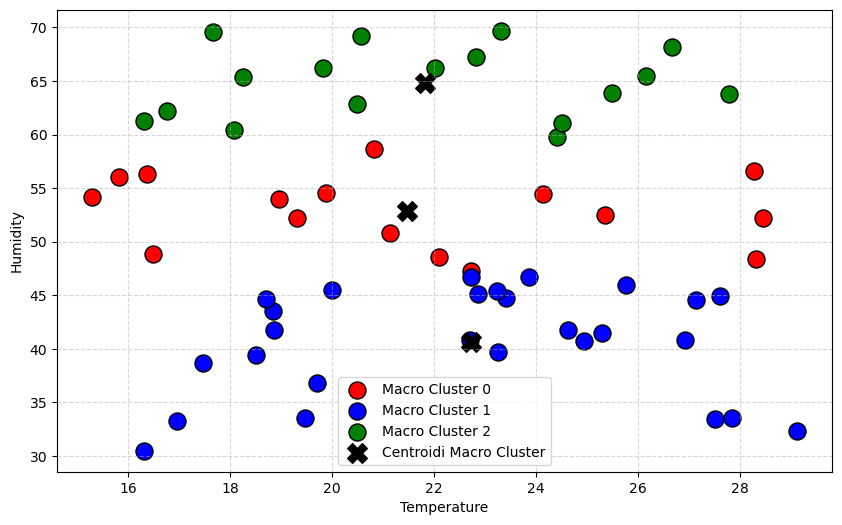

Querying data from 2026-03-13T17:12:18Z to 2026-03-13T17:13:29Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


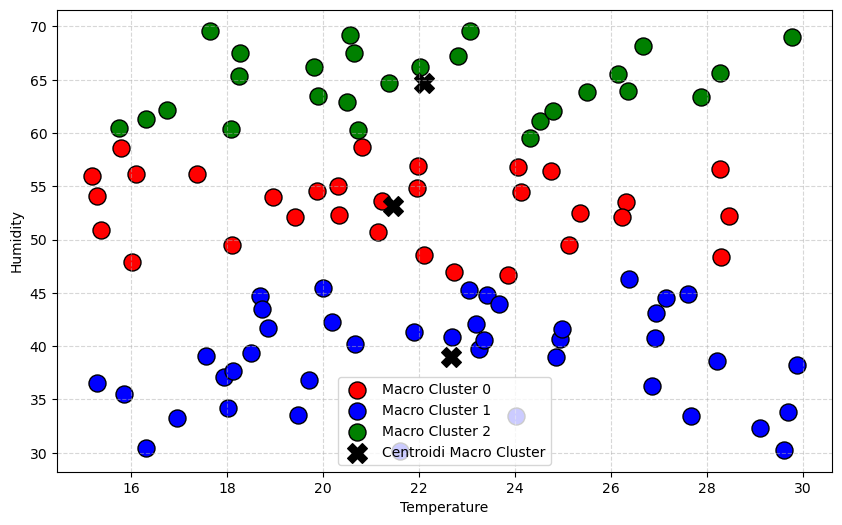

Querying data from 2026-03-13T17:13:29Z to 2026-03-13T17:14:41Z...


c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


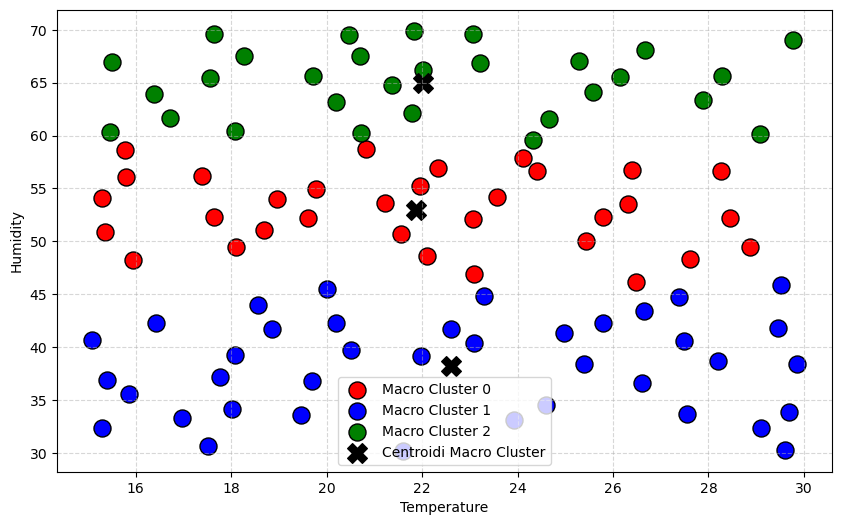

In [14]:
# MAIN
# Inizializzo il modello CluStream
clustream_model = cluster.CluStream(n_microclusters=10, time_window=1000)

# Ciclo di clustering
for i in range(len(time_interval)-1):
    start_time = time_interval[i]
    end_time = time_interval[i+1]

    print(f"Querying data from {start_time} to {end_time}...")
    sensor_data = query_sensor_data(client, bucket_name, start_time, end_time)

    if not sensor_data.empty:
        clustream_model = perform_incremental_clustering(sensor_data, clustream_model)
        visualize_macro_clusters(clustream_model, n_macro_clusters=3)

client.close()
        